In [1]:
%load_ext autoreload
%autoreload 2
%xmode verbose

Exception reporting mode: Verbose


In [2]:
# from ExoRM.get_data import get_data
# get_data()

# from ExoRM.initialize_model import initialize_model
# initialize_model()

# Use these to initialize / update the model

In [3]:
from ExoRM import read_rm_data, load_model, ForecasterRM, preprocess_data

import numpy
import matplotlib.pyplot as plot
import matplotlib
import pandas
import seaborn
import math
import time

save = True # save the figures / csv to files
plot.style.use('seaborn-v0_8-paper')
seaborn.set_theme(style = 'white', context = 'paper')
matplotlib.rcParams['figure.figsize'] = [4, 3]
matplotlib.rcParams['axes.labelsize'] = 10  # Axis label font size
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['figure.dpi'] = 300
matplotlib.rcParams['figure.constrained_layout.use'] = True

matplotlib.rcParams['lines.markersize'] = 1.2  # Default marker size (scatter size)
matplotlib.rcParams['lines.linewidth'] = 2   # Default line width

path = 'Paper Material/ExoRM'

data = read_rm_data()
data = preprocess_data(data)
data = data[['name', 'radius', 'mass', 'density', 'error']]

data

,name,radius,mass,density,error
0,2MASS J02192210-3925225 b,16.140960,4417.837000,1.050562,0.049985
1,55 Cnc e,1.875000,7.990000,1.212113,0.028071
2,BD-14 3065 b,21.590000,3932.000000,0.390711,0.060558
3,CFHTWIR-Oph 98 b,20.848704,2479.061575,0.273558,0.061518
4,CoRoT-1 b,19.223435,390.930900,0.055031,0.049397
...,...,...,...,...,...
960,XO-3 b,13.988832,3759.928900,1.373521,0.036115
961,XO-4 b,15.020060,512.341960,0.151198,0.027186
962,XO-5 b,12.780000,378.200000,0.181188,0.025901
963,XO-7 b,15.356304,225.658169,0.062315,0.032076


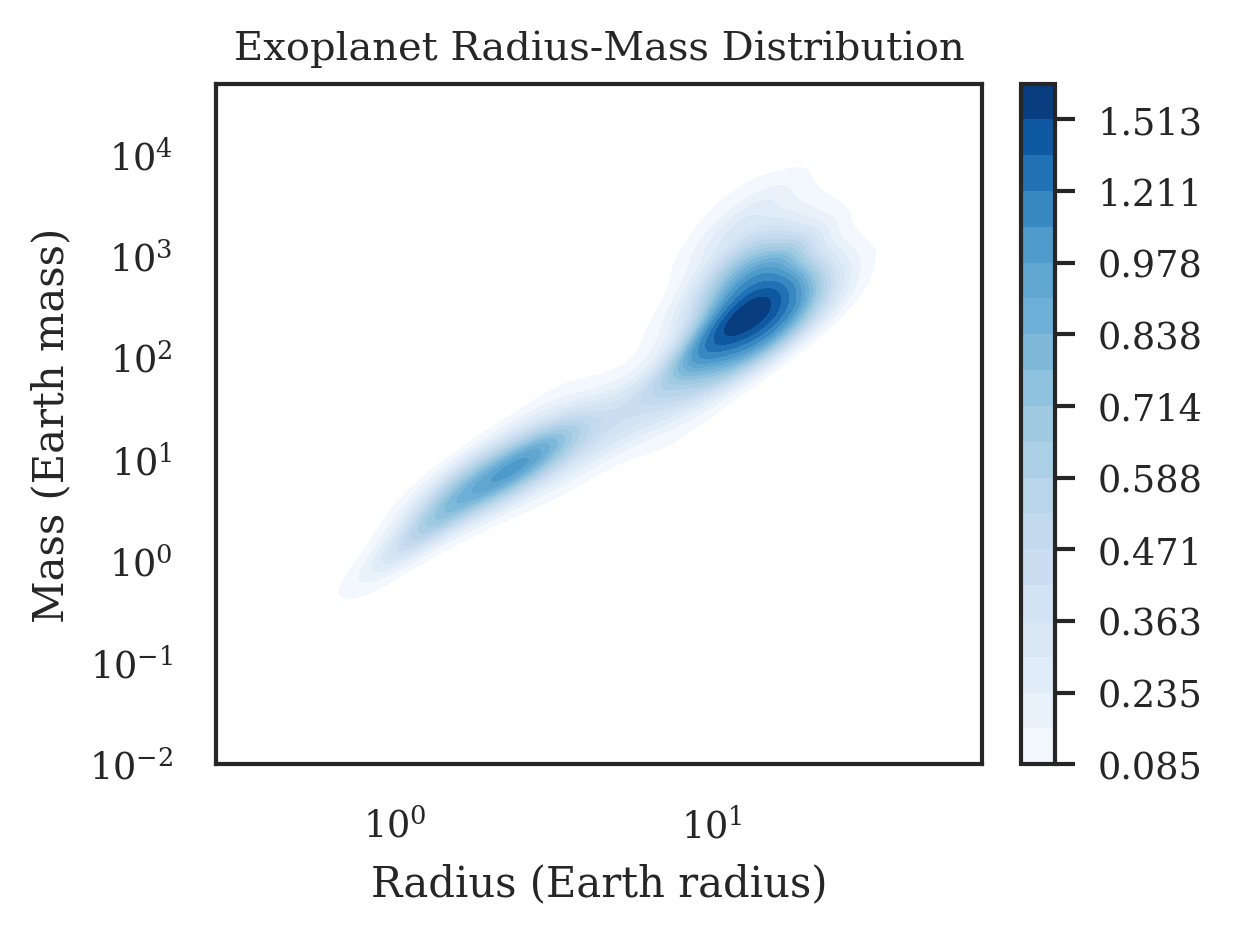

In [4]:
columns = ['radius', 'mass']

x = data['radius']
y = data['mass']

x = numpy.log10(x)
y = numpy.log10(y)
ax = seaborn.kdeplot(data, x = 'radius', y = 'mass', fill = True, cmap = 'Blues', levels = 20, cbar = True, log_scale = True)
# seaborn.scatterplot(numpy.log10(data[columns]), x = 'radius', y = 'mass', s = 5, color = 'black', zorder = 2)
# plot.gca().set_aspect('auto')

# plot.xlim(-0.3, 1.6)
# plot.ylim(-0.75, 4.25)

plot.xlabel('Radius (Earth radius)')
plot.ylabel('Mass (Earth mass)')
plot.title('Exoplanet Radius-Mass Distribution')

# if save: plot.savefig(f'{path}/Figure 1.jpeg')

plot.show()

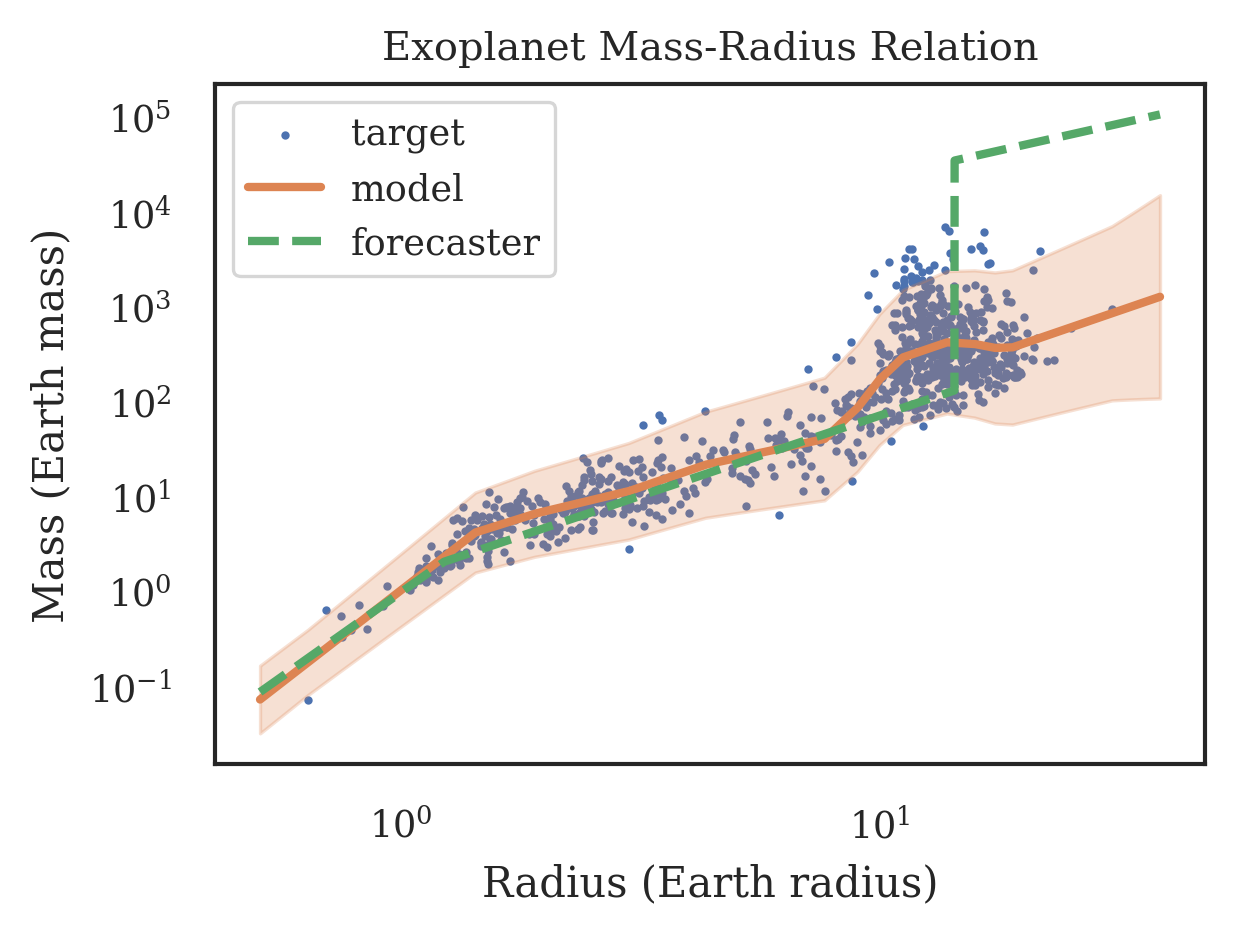

In [5]:
model = load_model()

xs = numpy.linspace(x.min() - 0.1, x.max() + 0.1, 10000)

ms = model(xs)
ms_e = model.error(xs)
ms2 = ForecasterRM.forecaster(xs)

plot.scatter(10 ** x, 10 ** y)
plot.plot(10 ** xs, 10 ** ms, color = 'C1')
plot.plot(10 ** xs, 10 ** ms2, '--', color = 'C2')

plot.fill_between(10 ** xs, 10 ** (ms - ms_e), 10 ** (ms + ms_e), color = 'C1', alpha = 0.25)

plot.legend(['target', 'model', 'forecaster'])
plot.xlabel('Radius (Earth radius)')
plot.ylabel('Mass (Earth mass)')
plot.title('Exoplanet Mass-Radius Relation')

plot.loglog()

if save: plot.savefig(f'{path}/Figure 2.jpeg')

plot.show()

In [6]:
m = model(x)
m_e = model.error(x)
out_error = len(x[(y < (m - m_e)) | (y > (m + m_e))])
out_error / len(x)

0.05284974093264249

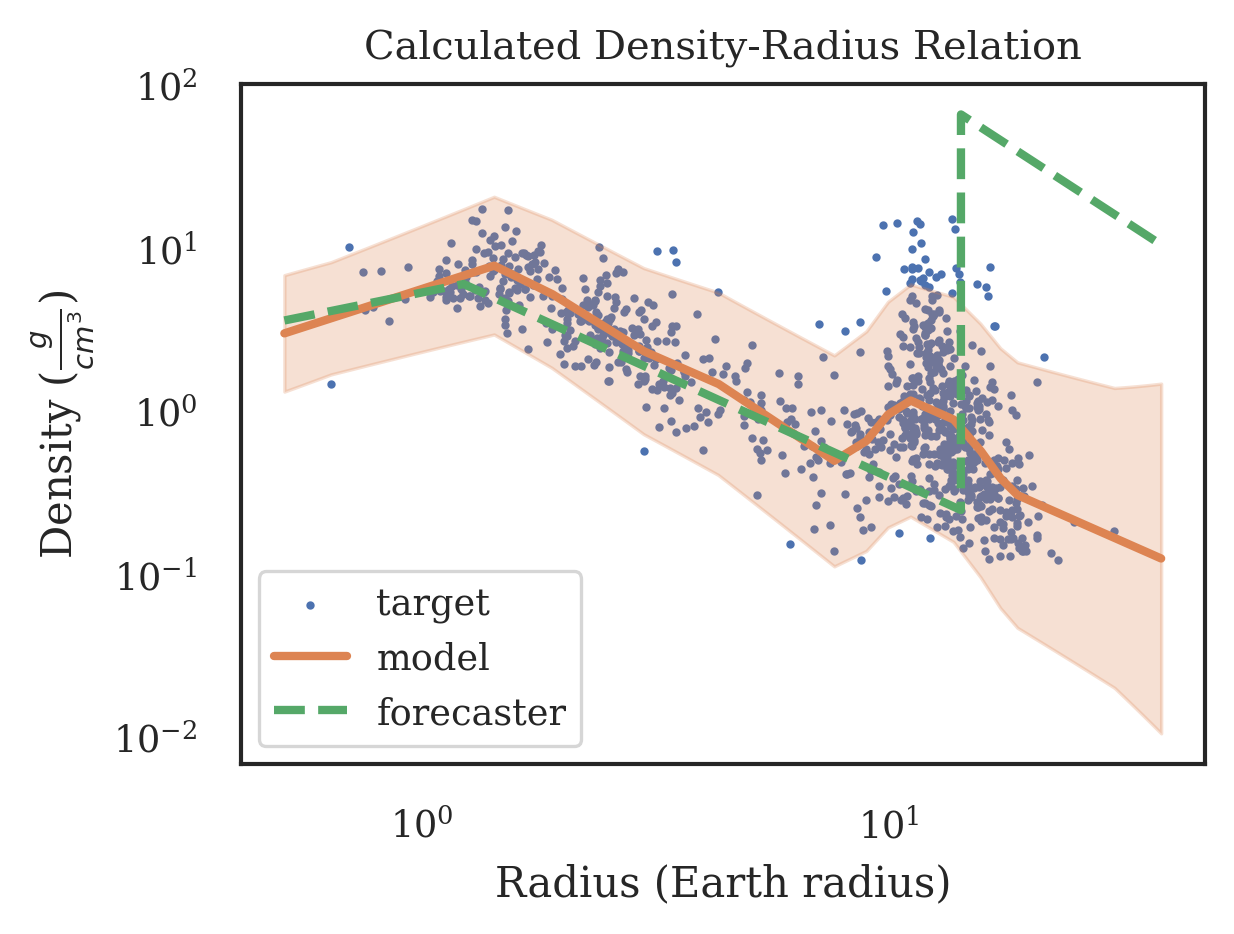

In [7]:
a = numpy.log10(5.51)  # Density of Earth in g / cm^3

plot.scatter(10 ** x, 10 ** ((y - 3 * x) + a))
ds = (ms - 3 * xs) + a
ds2 = (ms2 - 3 * xs) + a
plot.plot(10 ** xs, 10 ** ds, color = 'C1')
plot.plot(10 ** xs, 10 ** ds2, '--', color = 'C2')

plot.fill_between(10 ** xs,
                  10 ** (((ms - ms_e) - 3 * xs) + a),
                  10 ** (((ms + ms_e) - 3 * xs) + a),
                  color = 'C1', alpha = 0.25)

plot.legend(['target', 'model', 'forecaster'])
plot.xlabel('Radius (Earth radius)')
plot.ylabel('Density (${\\frac{g}{cm^3}}$)')
plot.title('Calculated Density-Radius Relation')

plot.loglog()

if save: plot.savefig(f'{path}/Figure 4.jpeg')

plot.show()

In [8]:
ms1ts = []
ms2ts = []

for i in range(100):
    start_time = time.time()
    model(xs)
    ms1t = time.time() - start_time

    start_time = time.time()
    ForecasterRM.forecaster(xs)
    ms2t = time.time() - start_time

    ms1ts.append(ms1t)
    ms2ts.append(ms2t)

ms1t = numpy.mean(ms1ts) * 1e3
ms2t = numpy.mean(ms2ts) * 1e3

print('ExoRM time (ms): ', ms1t)
print('Forecaster time (ms): ', ms2t)

ExoRM time (ms):  0.1056981086730957
Forecaster time (ms):  0.0958871841430664


In [9]:
p_data = data.copy()
columns = ['radius', 'mass']
p_data[columns] = numpy.log10(p_data[columns])

p_data

,name,radius,mass,density,error
0,2MASS J02192210-3925225 b,1.207929,3.645210,1.050562,0.049985
1,55 Cnc e,0.273001,0.902547,1.212113,0.028071
2,BD-14 3065 b,1.334253,3.594614,0.390711,0.060558
3,CFHTWIR-Oph 98 b,1.319079,3.394287,0.273558,0.061518
4,CoRoT-1 b,1.283831,2.592100,0.055031,0.049397
...,...,...,...,...,...
960,XO-3 b,1.145781,3.575180,1.373521,0.036115
961,XO-4 b,1.176672,2.709560,0.151198,0.027186
962,XO-5 b,1.106531,2.577722,0.181188,0.025901
963,XO-7 b,1.186287,2.353451,0.062315,0.032076


In [10]:
p_data['ExoRM'] = model(p_data['radius'])
p_data['Forecaster'] = ForecasterRM.forecaster(p_data['radius'])

p_data['ExoRM res'] = (p_data['mass'] - p_data['ExoRM'])
p_data['Forecaster res'] = (p_data['mass'] - p_data['Forecaster'])

p_data['name_len'] = p_data['name'].str.len()
p_data = p_data.sort_values(
    by = ['name_len', 'name'],
).reset_index(drop = True)
p_data = p_data.drop(columns = ['name_len'])

columns = ['radius', 'mass', 'ExoRM', 'Forecaster', 'ExoRM res', 'Forecaster res']

p_data[columns] = p_data[columns].map(
    lambda x: x if x == 0 or math.isnan(x) else round(x, (5 - 1) - int(math.floor(math.log10(abs(x)))))
)

p_data['winner'] = p_data.apply(
    lambda x: 'ExoRM' if abs(10 ** x['ExoRM'] - 10 ** x['mass']) < abs(10 ** x['Forecaster'] - 10 ** x['mass']) else 'Forecaster', axis = 1
)

if save: p_data[['name'] + columns + ['winner']].to_csv(f'{path}/ExoRM_results.csv', index = False)

p_data.head(10)

,name,radius,mass,density,error,ExoRM,Forecaster,ExoRM res,Forecaster res,winner
0,PH2 b,0.97021,1.93990,0.106982,0.136356,2.04800,1.80430,-0.108090,0.135680,Forecaster
1,K2-3 b,0.31765,0.70842,0.569488,0.080316,0.86342,0.69634,-0.155000,0.012079,Forecaster
2,K2-3 d,0.18469,1.04530,3.099193,0.193605,0.66569,0.47061,0.379630,0.574710,ExoRM
3,XO-1 b,1.13090,2.46270,0.117469,0.039260,2.61230,2.07710,-0.149660,0.385560,ExoRM
4,XO-3 b,1.14580,3.57520,1.373521,0.036115,2.62530,2.10230,0.949880,1.472800,ExoRM
5,XO-4 b,1.17670,2.70960,0.151198,0.027186,2.61600,4.57060,0.093591,-1.861000,ExoRM
6,XO-5 b,1.10650,2.57770,0.181188,0.025901,2.56990,2.03570,0.007784,0.542020,ExoRM
7,XO-7 b,1.18630,2.35350,0.062315,0.032076,2.61310,4.58150,-0.259610,-2.228000,ExoRM
8,GPX-1 b,1.21690,3.79670,1.399615,0.074623,2.59010,4.61620,1.206600,-0.819550,ExoRM
9,K2-18 b,0.41664,0.93601,0.485388,0.094882,0.98340,0.86442,-0.047394,0.071596,ExoRM


In [11]:
p_data['Percent ExoRM err'] = 100 * (((10 ** p_data['ExoRM']) - (10 ** p_data['mass'])) / (10 ** p_data['mass'])).abs()
p_data['Percent Forecaster err'] = 100 * (((10 ** p_data['Forecaster']) - (10 ** p_data['mass'])) / (10 ** p_data['mass'])).abs()

p_data['SAPE ExoRM'] = 100 * (((10 ** p_data['ExoRM']) - (10 ** p_data['mass'])) / ((10 ** p_data['mass'] + 10 ** p_data['ExoRM']) / 2)).abs()
p_data['SAPE Forecaster'] = 100 * (((10 ** p_data['Forecaster']) - (10 ** p_data['mass'])) / ((10 ** p_data['mass'] + 10 ** p_data['Forecaster']) / 2)).abs()

p_data[['Percent ExoRM err', 'Percent Forecaster err', 'SAPE ExoRM', 'SAPE Forecaster', 'ExoRM res', 'Forecaster res']].abs().describe()

,Percent ExoRM err,Percent Forecaster err,SAPE ExoRM,SAPE Forecaster,ExoRM res,Forecaster res
count,965.000000,965.000000,965.000000,965.000000,965.000000,965.000000
mean,60.724160,2965.135254,51.065209,96.762805,0.244252,0.725957
std,68.642981,6882.242905,40.215700,68.949060,0.220203,0.764540
min,0.174843,0.046062,0.174996,0.046052,0.000763,0.000195
25%,18.631494,31.470115,18.368769,33.767904,0.080046,0.148070
50%,42.017091,60.244246,41.943148,80.628283,0.184940,0.371230
75%,76.099884,95.055755,73.387088,172.024878,0.334300,1.123700
max,522.586931,44743.551464,177.542283,199.109995,1.225500,2.651700


In [12]:
f_data = p_data[p_data['radius'] <= numpy.log10(11.1)]
f_data[['Percent ExoRM err', 'Percent Forecaster err', 'SAPE ExoRM', 'SAPE Forecaster', 'ExoRM res', 'Forecaster res']].abs().describe()

,Percent ExoRM err,Percent Forecaster err,SAPE ExoRM,SAPE Forecaster,ExoRM res,Forecaster res
count,477.000000,477.000000,477.000000,477.000000,477.000000,477.000000
mean,46.993635,42.124470,39.660837,48.980423,0.184515,0.235378
std,58.574350,38.273243,34.195544,38.776005,0.178741,0.225616
min,0.174843,0.062150,0.174996,0.062170,0.000763,0.000266
25%,12.943741,19.131386,12.592277,18.711189,0.054731,0.081514
50%,31.297902,34.521307,31.311107,38.930881,0.137110,0.171260
75%,57.493045,55.710579,54.366793,70.520668,0.242120,0.319980
max,485.328944,388.674863,176.392962,189.867490,1.202600,1.585200


In [13]:
p_data['winner'].value_counts() / len(p_data), f_data['winner'].value_counts() / len(f_data)

(winner
 ExoRM         0.726425
 Forecaster    0.273575
 Name: count, dtype: float64,
 winner
 ExoRM         0.620545
 Forecaster    0.379455
 Name: count, dtype: float64)

In [14]:
f_x = x[x < numpy.log10(11.1)]
numpy.mean(model(f_x) - ForecasterRM.forecaster(f_x))
# average change metween two models in the < 11.1 radius

0.15737196655072946

In [15]:
f_comparison = pandas.DataFrame(
    [[numpy.mean(model(f_x)), numpy.mean(ForecasterRM.forecaster(f_x))],
     [f_data['ExoRM res'].abs().mean(), f_data['Forecaster res'].abs().mean()],
     [f_data['ExoRM res'].abs().max(), f_data['Forecaster res'].abs().max()],
     [f_data['Percent ExoRM err'].mean(), f_data['Percent Forecaster err'].mean()],
     [f_data['Percent ExoRM err'].median(), f_data['Percent Forecaster err'].median()],
     [f_data['SAPE ExoRM'].mean(), f_data['SAPE Forecaster'].mean()],
     [100 * f_data['winner'].value_counts()['ExoRM'] / len(f_data), 100 * f_data['winner'].value_counts()['Forecaster'] / len(f_data)]
     ],
    columns = ['ExoRM', 'Forecaster'])

f_comparison['Difference'] = f_comparison['ExoRM'] - f_comparison['Forecaster']

f_comparison = f_comparison.map(
    lambda x: x if x == 0 or math.isnan(x) else round(x, (5 - 1) - int(math.floor(math.log10(abs(x)))))
)

if save: f_comparison.to_csv(f'{path}/filtered_comparison.csv', index = False)

f_comparison

,ExoRM,Forecaster,Difference
0,1.21090,1.05360,0.157370
1,0.18451,0.23538,-0.050863
2,1.20260,1.58520,-0.382600
3,46.99400,42.12400,4.869200
4,31.29800,34.52100,-3.223400
5,39.66100,48.98000,-9.319600
6,62.05500,37.94500,24.109000


In [16]:
from scipy.stats import ttest_rel
stat, val = ttest_rel(f_data['Percent ExoRM err'], f_data['Percent Forecaster err'])
stat, val

(2.2615224085738723, 0.024177337579926766)

In [17]:
stat, val = ttest_rel(f_data['SAPE ExoRM'], f_data['SAPE Forecaster'])
stat, val

(-6.159216632235891, 1.5567323807562907e-09)

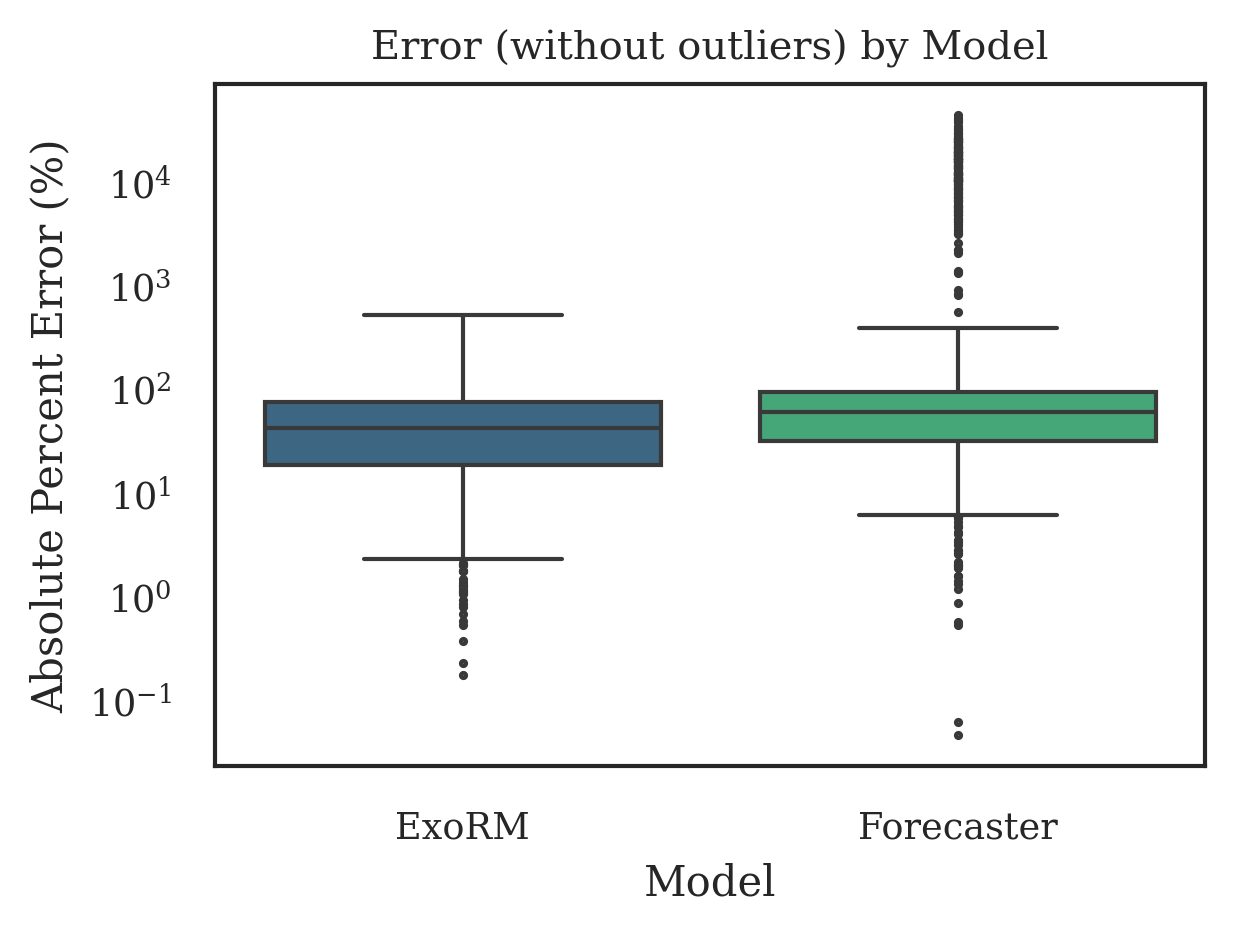

,Model,Absolute Percent Error (%)
0,ExoRM,28.262588
1,ExoRM,42.889396
2,ExoRM,58.275610
3,ExoRM,41.123715
4,ExoRM,88.777232
...,...,...
1925,Forecaster,41.874059
1926,Forecaster,49.014111
1927,Forecaster,11.018443
1928,Forecaster,44.677168


In [ ]:
p_data_long = pandas.melt(
    p_data,
    value_vars = ['Percent ExoRM err', 'Percent Forecaster err'],
    var_name = 'Model',
    value_name = 'Absolute Percent Error (%)'
)

p_data_long['Model'] = p_data_long['Model'].map(lambda x: 'ExoRM' if x == 'Percent ExoRM err' else 'Forecaster')

ax = seaborn.boxplot(data = p_data_long, x = 'Model', y = 'Absolute Percent Error (%)', hue = 'Model', palette = 'viridis', zorder = 1, whis = 1.5, showfliers = True, log_scale = True)

plot.title('Error (without outliers) by Model')

if save: plot.savefig(f'{path}/Figure 3.jpeg')

plot.show()

p_data_long

In [19]:
exoplanet_data = read_rm_data()
exoplanet_data = preprocess_data(exoplanet_data)
new_exoplanet_data = exoplanet_data[exoplanet_data['pl_pubdate'] >= '2018']
old_exoplanet_data = exoplanet_data[exoplanet_data['pl_pubdate'] < '2018']
new_exoplanet_data, old_exoplanet_data

(                 name     radius         mass     error pl_pubdate   density
 1            55 Cnc e   1.875000     7.990000  0.028071    2018-10  1.212113
 2        BD-14 3065 b  21.590000  3932.000000  0.060558    2024-03  0.390711
 3    CFHTWIR-Oph 98 b  20.848704  2479.061575  0.061518    2020-12  0.273558
 11         CoRoT-18 b  12.845514  1048.839000  0.047767    2019-02  0.494828
 17         CoRoT-30 b  11.309881   921.707000  0.075592    2020-03  0.637116
 ..                ...        ...          ...       ...        ...       ...
 931         WASP-76 b  20.781450   284.138596  0.028181    2020-04  0.031659
 956        Wolf 327 b   1.240000     2.530000  0.115103    2024-01  1.326953
 957        Wolf 503 b   2.043000     6.260000  0.072398    2021-12  0.734124
 963            XO-7 b  15.356304   225.658169  0.032076    2024-10  0.062315
 964          pi Men c   2.110000     4.300000  0.093244    2020-10  0.457742
 
 [661 rows x 6 columns],
                           name     r

In [20]:
len(new_exoplanet_data) / len(exoplanet_data)

0.6849740932642487

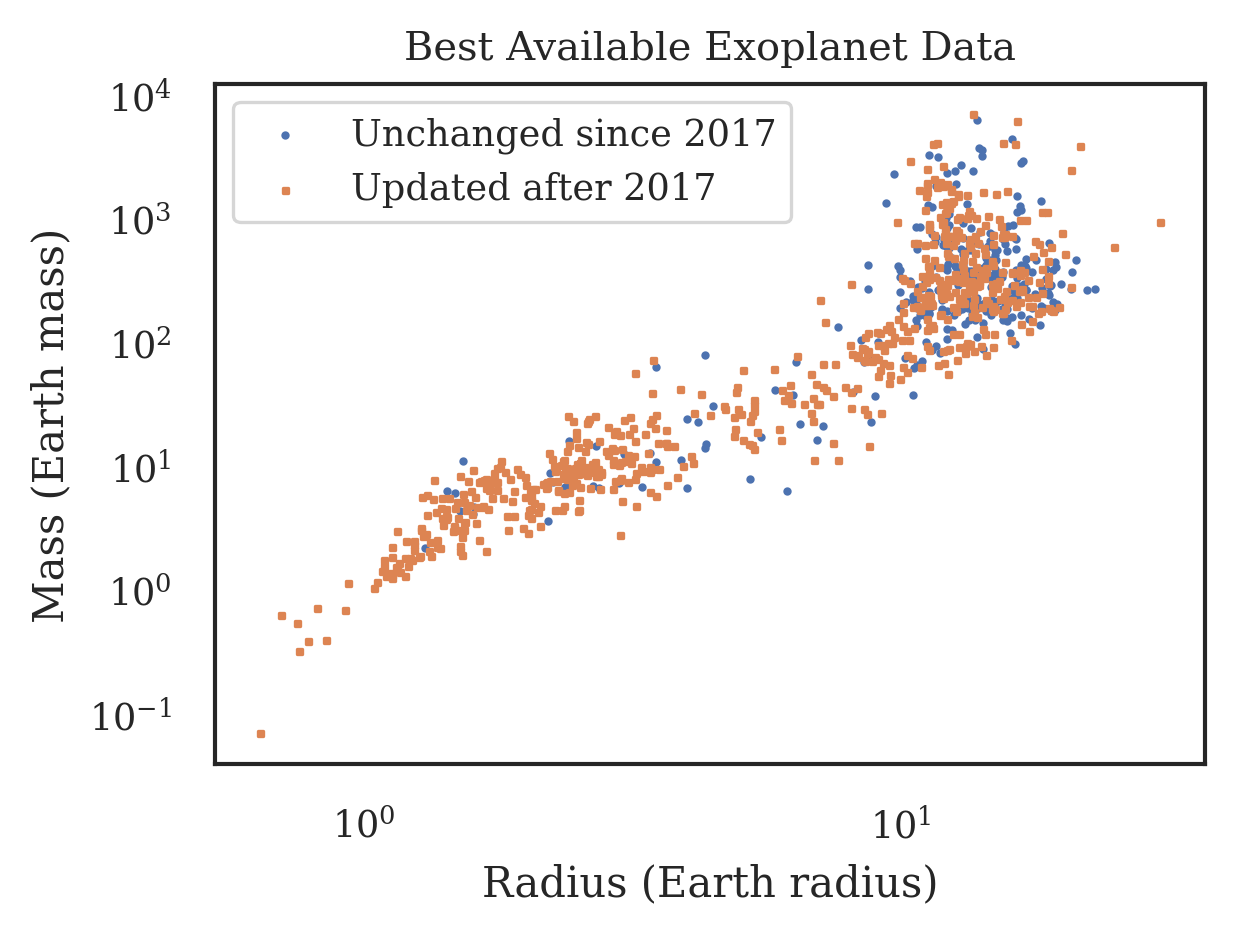

In [21]:
plot.scatter(old_exoplanet_data['radius'], old_exoplanet_data['mass'], marker = 'o')
plot.scatter(new_exoplanet_data['radius'], new_exoplanet_data['mass'], marker = 's')
plot.legend(['Unchanged since 2017', 'Updated after 2017'])

plot.xlabel('Radius (Earth radius)')
plot.ylabel('Mass (Earth mass)')
plot.title('Best Available Exoplanet Data')

plot.loglog()

if save: plot.savefig(f'{path}/Figure 1.jpeg')

plot.show()